# ☕ Preprocesamiento + Modelado
### Proyecto Grupal — Clasificación de Calidad de Café

---

## 🗺️ Hoja de Ruta de este Notebook

| Bloque | Qué vamos a hacer |
|--------|-------------------|
| **1** | Cargar el dataset limpio del EDA |
| **2** | Limpieza final (eliminar columnas inútiles) |
| **3** | Imputación de valores nulos |
| **4** | Encoding de variables categóricas |
| **5** | Escalado de variables numéricas |
| **6** | Split Train / Test |
| **7** | Modelos Baseline (Logistic Regression) |
| **8** | Modelos Avanzados (Random Forest) |
| **9** | Comparación de modelos y selección del mejor |
| **10** | Análisis del modelo ganador (Matriz de confusión, ROC, Feature Importance) |
| **11** | Guardar el modelo entrenado |

---


> ⚠️ **Importante:** Usamos `01_EDA_Merge_Jonathan.ipynb` con el CSV limpio guardado.

---
## 📦 BLOQUE 0 — Importar librerías

Añadimos librerías nuevas respecto al EDA:
- `sklearn` → preprocesamiento, modelos, métricas
- `xgboost` → modelo de boosting avanzado
- `joblib` → guardar/cargar el modelo entrenado

In [232]:
# ─── Librerías base ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Preprocesamiento ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ─── Modelos ──────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# ─── Métricas ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

# ─── Guardar modelo ───────────────────────────────────────────────────────────
import joblib

# ─── Configuración visual ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
## 📂 BLOQUE 1 — Cargar el dataset del EDA

Cargamos el CSV `coffee_quality_eda_fusion_clean_Jonathan.csv`

In [233]:
# Cargamos el dataset limpio generado por el EDA
df = pd.read_csv('../data/processed/coffee_quality_eda_fusion_clean_Jonathan.csv')

print(f'✅ Dataset cargado')
print(f'📊 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'\n🎯 Distribución del target:')
print(df['quality_label'].value_counts())
df.head()

✅ Dataset cargado
📊 Dimensiones: 1512 filas x 23 columnas

🎯 Distribución del target:
quality_label
Specialty       834
No Specialty    678
Name: count, dtype: int64


,Acidity,Aftertaste,Aroma,Balance,Body,Category One Defects,Category Two Defects,Clean Cup,Color,Country of Origin,...,Moisture Percentage,Processing Method,Quakers,Region,Sweetness,Uniformity,Variety,altitud_limpia,dataset_source,quality_label
0,8.75,8.67,8.67,8.42,8.50,0,0,10.0,Green,Ethiopia,...,0.12,Washed / Wet,0.0,guji-hambela,10.0,10.0,NaN,2075.0,2018_volpatto,Specialty
1,8.58,8.50,8.75,8.42,8.42,0,1,10.0,Green,Ethiopia,...,0.12,Washed / Wet,0.0,guji-hambela,10.0,10.0,Other,2075.0,2018_volpatto,Specialty
2,8.42,8.42,8.42,8.42,8.33,0,0,10.0,NaN,Guatemala,...,0.00,NaN,0.0,NaN,10.0,10.0,Bourbon,1700.0,2018_volpatto,Specialty
3,8.42,8.42,8.17,8.25,8.50,0,2,10.0,Green,Ethiopia,...,0.11,Natural / Dry,0.0,oromia,10.0,10.0,NaN,2000.0,2018_volpatto,Specialty
4,8.50,8.25,8.25,8.33,8.42,0,2,10.0,Green,Ethiopia,...,0.12,Washed / Wet,0.0,guji-hambela,10.0,10.0,Other,2075.0,2018_volpatto,Specialty


In [234]:
print (df.columns)

Index(['Acidity', 'Aftertaste', 'Aroma', 'Balance', 'Body',
       'Category One Defects', 'Category Two Defects', 'Clean Cup', 'Color',
       'Country of Origin', 'Flavor', 'Grading Date', 'Harvest Year',
       'Moisture Percentage', 'Processing Method', 'Quakers', 'Region',
       'Sweetness', 'Uniformity', 'Variety', 'altitud_limpia',
       'dataset_source', 'quality_label'],
      dtype='str')


---
## 🧹 BLOQUE 2 — Limpieza final

### ¿Qué eliminamos y por qué?

| Columna | Motivo de eliminación |
|---------|----------------------|
| `Uniformity` | Varianza casi 0 (todos valen ~10). El modelo no aprende nada de ella |
| `Sweetness` | Todos los valores son exactamente 10. Sin varianza |
| `Clean Cup` | Igual que Sweetness, sin variación |
| Metadata | Que aún tengamos. |

**Regla:** Una variable sin varianza es como un semáforo que siempre está en verde — no te da información sobre cuándo parar.

In [235]:
# ─── Columnas a eliminar ──────────────────────────────────────────────────────

# Metadata que no aporta valor predictivo
metadata = [
    'Unnamed: 0', 'ID', 'Farm Name', 'Lot Number', 'Mill',
    'ICO Number', 'Company', 'In-Country Partner', 'Producer',
    'Bag Weight', 'Number of Bags', 'Expiration',
    'Certification Body', 'Certification Address', 'Certification Contact',
    'Owner', 'Grading Date', 'Status', 'Region',
    'Harvest Year',       # Fecha de cosecha — no predice calidad
    'dataset_source'      # Columna de auditoría — solo indica origen del dato
]

# Variables sin varianza (inútiles para el modelo)
sin_varianza = ['Uniformity', 'Sweetness', 'Clean Cup', 'Defects']

# Unimos todas las columnas a eliminar
cols_eliminar = metadata + sin_varianza

# Solo eliminamos las que realmente existen en el dataset
cols_eliminar = [c for c in cols_eliminar if c in df.columns]

df_model = df.drop(columns=cols_eliminar)

print(f'✅ Columnas eliminadas: {len(cols_eliminar)}')
print(f'📊 Dimensiones restantes: {df_model.shape[0]} filas x {df_model.shape[1]} columnas')
print(f'\n📝 Columnas que quedan:')
for i, col in enumerate(df_model.columns, 1):
    print(f'  {i:02d}. {col} ({df_model[col].dtype})')

✅ Columnas eliminadas: 7
📊 Dimensiones restantes: 1512 filas x 16 columnas

📝 Columnas que quedan:
  01. Acidity (float64)
  02. Aftertaste (float64)
  03. Aroma (float64)
  04. Balance (float64)
  05. Body (float64)
  06. Category One Defects (int64)
  07. Category Two Defects (int64)
  08. Color (str)
  09. Country of Origin (str)
  10. Flavor (float64)
  11. Moisture Percentage (float64)
  12. Processing Method (str)
  13. Quakers (float64)
  14. Variety (str)
  15. altitud_limpia (float64)
  16. quality_label (str)


---
## 🗂️ BLOQUE 2b — Agrupar categorías minoritarias

**¿Por qué agrupar?**  
`Processing Method` tiene 12 categorías pero 4 de ellas acumulan el 98% de los datos.  
Las 8 restantes tienen 1–5 muestras: el modelo intentaría aprender de casos únicos → ruido puro.  

`Country of Origin` tiene 37 países pero muchos tienen <30 muestras.  
Con LabelEncoder, un país que aparece 2 veces recibe un número (ej: 14) que el modelo  
trata igual que Colombia (239 muestras). Eso introduce sesgo.  

**Solución:** conservar las categorías con masa estadística real y agrupar el resto en `'Other'`.


In [236]:
# ─── Agrupar Processing Method ───────────────────────────────────────────────
# Solo 4 métodos tienen suficientes muestras para ser estadísticamente válidos
metodos_principales = ['Washed / Wet', 'Natural / Dry',
                        'Semi-Washed / Semi-Pulped', 'Pulped Natural / Honey']

df_model['Processing Method'] = df_model['Processing Method'].apply(
    lambda x: x if x in metodos_principales else 'Other'
)

print('📊 Processing Method tras agrupación:')
print(df_model['Processing Method'].value_counts())

# ─── Agrupar Country of Origin ────────────────────────────────────────────────
# Mantener solo países con >= 30 muestras (representación estadística real)
conteo_paises = df_model['Country of Origin'].value_counts()
paises_validos = conteo_paises[conteo_paises >= 30].index

df_model['Country of Origin'] = df_model['Country of Origin'].apply(
    lambda x: x if x in paises_validos else 'Other'
)

# Mantener solo variedades con >= 20 muestras
conteo_var = df_model['Variety'].value_counts()
variedades_validas = conteo_var[conteo_var >= 20].index

df_model['Variety'] = df_model['Variety'].apply(
    lambda x: x if x in variedades_validas else 'Other'
)



print(f'\n🌍 Country of Origin tras agrupación:')
print(df_model['Country of Origin'].value_counts())

print(f'\n☕ Variety tras agrupación:')
print(df_model['Variety'].value_counts())

print(f'\n✅ Processing Method: {df_model["Processing Method"].nunique()} categorías')
print(f'\n✅ Country of Origin:  {df_model["Country of Origin"].nunique()} categorías')
print(f'✅ Variety: {df_model["Variety"].nunique()} categorías')


📊 Processing Method tras agrupación:
Processing Method
Washed / Wet                 932
Natural / Dry                297
Other                        189
Semi-Washed / Semi-Pulped     55
Pulped Natural / Honey        39
Name: count, dtype: int64

🌍 Country of Origin tras agrupación:
Country of Origin
Mexico                          239
Other                           214
Guatemala                       202
Colombia                        202
Brazil                          142
Taiwan                          134
United States (Hawaii)           78
Honduras                         65
Costa Rica                       59
Ethiopia                         55
Tanzania, United Republic Of     46
Thailand                         44
Nicaragua                        32
Name: count, dtype: int64

☕ Variety tras agrupación:
Variety
Other             462
Caturra           283
Bourbon           243
Typica            232
Catuai             85
Hawaiian Kona      44
Gesha              39
Yellow Bourbon

---
## 🩹 BLOQUE 3 — Imputación de valores nulos

### ¿Qué es imputar?
Rellenar los valores vacíos con un valor calculado para no perder esas filas.

### Estrategia:
- **Variables numéricas** → rellenamos con la **mediana** (más robusta que la media ante outliers)
- **Variables categóricas** → rellenamos con la **moda** (el valor más frecuente)

### ¿Por qué mediana y no media?
Si la altitud tiene un outlier de 5400m, la media se dispara pero la mediana no se mueve.

In [237]:
# ─── Ver nulos restantes ──────────────────────────────────────────────────────
nulos = df_model.isnull().sum()
print('🕳️ Nulos antes de imputar:')
print(nulos[nulos > 0])

# ─── Separar columnas por tipo ────────────────────────────────────────────────
# Excluimos el target de la imputación
cols_numericas = df_model.select_dtypes(include=[np.number]).columns.tolist()

# select_dtypes con 'object' Y 'string' para cubrir ambos tipos pandas
cols_categoricas = df_model.select_dtypes(
    include=['object', 'string']
).columns.tolist()
cols_categoricas = [c for c in cols_categoricas if c != 'quality_label']

print(f'\n🔢 Numéricas ({len(cols_numericas)}): {cols_numericas}')
print(f'📝 Categóricas ({len(cols_categoricas)}): {cols_categoricas}')

# ─── Imputar numéricas con mediana ────────────────────────────────────────────
imp_num = SimpleImputer(strategy='median')
df_model[cols_numericas] = imp_num.fit_transform(df_model[cols_numericas])

# ─── Imputar categóricas con moda ─────────────────────────────────────────────
imp_cat = SimpleImputer(strategy='most_frequent')
df_model[cols_categoricas] = imp_cat.fit_transform(df_model[cols_categoricas])

# ─── CRÍTICO: forzar dtype object después de imputar ─────────────────────────
# SimpleImputer puede cambiar StringDtype → object internamente de forma
# inconsistente. Forzamos object para que select_dtypes funcione después.
for col in cols_categoricas:
    df_model[col] = df_model[col].astype(str)

print(f'\n✅ Nulos tras imputar: {df_model.isnull().sum().sum()}')
print(f'\n📋 Tipos tras imputar:')
print(df_model[cols_categoricas].dtypes)

🕳️ Nulos antes de imputar:
Color             266
Quakers             1
altitud_limpia    232
dtype: int64

🔢 Numéricas (11): ['Acidity', 'Aftertaste', 'Aroma', 'Balance', 'Body', 'Category One Defects', 'Category Two Defects', 'Flavor', 'Moisture Percentage', 'Quakers', 'altitud_limpia']
📝 Categóricas (4): ['Color', 'Country of Origin', 'Processing Method', 'Variety']

✅ Nulos tras imputar: 0

📋 Tipos tras imputar:
Color                str
Country of Origin    str
Processing Method    str
Variety              str
dtype: object


---
## 🔤 BLOQUE 4 — Encoding de variables categóricas

### ¿Por qué hay que encodear?
Los modelos de ML solo entienden números. El texto `'Specialty'` no significa nada para un algoritmo.
Tenemos que convertir cada categoría a un número.

### Métodos:
- **LabelEncoder** → Asigna un número entero a cada categoría (0, 1, 2...). Útil para árboles de decisión.
- **OneHotEncoder** → Crea una columna nueva por cada categoría con 0 o 1. Mejor para regresión logística.

Usamos **LabelEncoder** porque Random Forest y XGBoost lo manejan bien y no genera demasiadas columnas.

In [238]:
# ─── Encodear el target ───────────────────────────────────────────────────────
# VERSIÓN ROBUSTA: normaliza el string antes de comparar
df_model['quality_label'] = (
    df_model['quality_label']
    .astype(str)
    .str.strip()                    # elimina espacios invisibles
    .str.title()                    # normaliza capitalización
    .map({'Specialty': 1, 'No Specialty': 0})  # mapeo explícito
)

# Verificación de seguridad — si hay NaN, algo fue mal
nulos_target = df_model['quality_label'].isna().sum()
if nulos_target > 0:
    print(f'⚠️ ALERTA: {nulos_target} valores del target no se mapearon correctamente')
    print('Valores únicos encontrados:', df_model['quality_label'].unique())
else:
    print('✅ Target codificado correctamente')
    print(df_model['quality_label'].value_counts())
    print(f'   Specialty (1):    {(df_model["quality_label"]==1).sum()}')
    print(f'   No Specialty (0): {(df_model["quality_label"]==0).sum()}')

✅ Target codificado correctamente
quality_label
1    834
0    678
Name: count, dtype: int64
   Specialty (1):    834
   No Specialty (0): 678


---
## 🔗 BLOQUE 4b — Análisis de Multicolinealidad (VIF)

**¿Qué es la multicolinealidad?**  
Ocurre cuando dos o más variables predictoras están muy correlacionadas entre sí.  
En la matriz de correlación del EDA vimos que Flavor–Aftertaste tienen r=0.90, Balance–Aftertaste r=0.83, etc.  

**¿Por qué es un problema?**  
- Para **Logistic Regression**: infla los coeficientes y los hace inestables
- Para **Random Forest / XGBoost**: no es un problema grave, los árboles lo manejan solos

**Métrica: VIF (Variance Inflation Factor)**  
- VIF < 5 → sin problema  
- VIF 5–10 → multicolinealidad moderada, vigilar  
- VIF > 10 → multicolinealidad severa, considerar eliminar o trabajar con Ride/Lasso

In [239]:
# ─── VIF para detectar multicolinealidad ──────────────────────────────────────
# Solo sobre variables numéricas (las sensoriales, que son las sospechosas)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Tomamos solo las columnas numéricas del dataset codificado
cols_num_vif = df_model.select_dtypes(include=[np.number]).drop(columns=['quality_label']).columns.tolist()
X_vif = df_model[cols_num_vif].copy()

vif_data = pd.DataFrame()
vif_data['Variable'] = cols_num_vif
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print('📊 Variance Inflation Factor (VIF) por variable:')
print(vif_data.to_string(index=False))
print()
print('📌 Referencia: VIF < 5 = OK | VIF 5-10 = Moderado | VIF > 10 = Severo')
print()
print('💡 Nota: Para Random Forest y XGBoost los VIF altos no son críticos.')
print('         Solo afecta a Logistic Regression — cuyos coeficientes son inestables si VIF > 10.')

📊 Variance Inflation Factor (VIF) por variable:
            Variable         VIF
              Flavor 2656.359932
          Aftertaste 2272.644701
             Balance 1457.172142
             Acidity 1434.416061
                Body 1358.843122
               Aroma 1292.125545
Category Two Defects    1.719243
 Moisture Percentage    1.269959
Category One Defects    1.198248
             Quakers    1.111691
      altitud_limpia    1.055079

📌 Referencia: VIF < 5 = OK | VIF 5-10 = Moderado | VIF > 10 = Severo

💡 Nota: Para Random Forest y XGBoost los VIF altos no son críticos.
         Solo afecta a Logistic Regression — cuyos coeficientes son inestables si VIF > 10.


In [240]:
# ─── Encodear variables categóricas con LabelEncoder ─────────────────────────
# Convertimos texto a número para que el modelo pueda procesarlo.
# Guardamos cada encoder en un diccionario para reutilizarlos en la app.
encoders = {}

for col in cols_categoricas:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    print(f'  ✅ {col}: {len(le.classes_)} categorías → {list(le.classes_[:5])} ...')

# ─── Verificación: ninguna columna debe seguir siendo string ─────────────────
strings_restantes = df_model.select_dtypes(include=['object','string']).columns.tolist()
strings_restantes = [c for c in strings_restantes if c != 'quality_label']
if strings_restantes:
    print(f'\n⚠️ ALERTA: estas columnas siguen siendo string: {strings_restantes}')
else:
    print(f'\n✅ Todas las categóricas están codificadas como números')
    print(f'📊 Tipos de datos tras encoding:')
    print(df_model.dtypes)


  ✅ Color: 6 categorías → ['Blue-Green', 'Bluish-Green', 'Brown', 'Green', 'Yellow'] ...
  ✅ Country of Origin: 13 categorías → ['Brazil', 'Colombia', 'Costa Rica', 'Ethiopia', 'Guatemala'] ...
  ✅ Processing Method: 5 categorías → ['Natural / Dry', 'Other', 'Pulped Natural / Honey', 'Semi-Washed / Semi-Pulped', 'Washed / Wet'] ...
  ✅ Variety: 11 categorías → ['Bourbon', 'Catimor', 'Catuai', 'Caturra', 'Gesha'] ...

✅ Todas las categóricas están codificadas como números
📊 Tipos de datos tras encoding:
Acidity                 float64
Aftertaste              float64
Aroma                   float64
Balance                 float64
Body                    float64
Category One Defects    float64
Category Two Defects    float64
Color                     int64
Country of Origin         int64
Flavor                  float64
Moisture Percentage     float64
Processing Method         int64
Quakers                 float64
Variety                   int64
altitud_limpia          float64
quality_labe

---
## ⚖️ BLOQUE 5 — Escalado de variables numéricas

### ¿Por qué escalar?
Imagina que tienes Aroma (valores entre 6.5 y 8.5) y altitud (valores entre 500 y 2500).
Los modelos basados en distancias o gradientes (como Logistic Regression) se "dejan llevar"
por la variable con números más grandes. El escalado iguala el campo de juego.

### ¿Cuándo NO es necesario?
Los modelos basados en árboles (Decision Tree, Random Forest, XGBoost) **no necesitan escalado**.
Pero lo aplicamos igual para que Logistic Regression funcione correctamente.

### StandardScaler:
Transforma cada variable para que tenga **media = 0** y **desviación estándar = 1**.

In [241]:
# ─── Separar features y target ────────────────────────────────────────────────
X = df_model.drop(columns=['quality_label'])
y = df_model['quality_label']

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'\nColumnas del modelo:')
print(list(X.columns))

Features (X): (1512, 15)
Target  (y): (1512,)

Columnas del modelo:
['Acidity', 'Aftertaste', 'Aroma', 'Balance', 'Body', 'Category One Defects', 'Category Two Defects', 'Color', 'Country of Origin', 'Flavor', 'Moisture Percentage', 'Processing Method', 'Quakers', 'Variety', 'altitud_limpia']


---
## ✂️ BLOQUE 6 — Split Train / Test

### ¿Por qué dividir el dataset?
El modelo aprende con los datos de entrenamiento (train). Los datos de test los guarda en un cajón y
solo los abre al final para ver si el modelo generaliza bien o si hizo trampa (memorización = overfitting).

### `stratify=y`
Garantiza que tanto train como test tengan la misma proporción de Specialty/No Specialty.
Sin esto, podría ocurrir que el test tenga muy pocos No Specialty y las métricas sean engañosas.

### División: 80% train / 20% test
Con 1512 filas: ~1209 para entrenar, ~303 para testear.

In [242]:
# ─── Split ────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% para test
    random_state=42,      # semilla para reproducibilidad (siempre el mismo split)
    stratify=y            # mantener proporciones de clases
)

print(f'📊 Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'📊 Test:  {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\n🎯 Distribución en Train:')
print(y_train.value_counts())
print(f'\n🎯 Distribución en Test:')
print(y_test.value_counts())

# ─── Escalar DESPUÉS del split ────────────────────────────────────────────────
# MUY IMPORTANTE: el scaler aprende solo con train, no con test
# Si escalamos antes del split, habría data leakage (el test contamina el train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform en train
X_test_scaled  = scaler.transform(X_test)         # solo transform en test

print('\n✅ Escalado completado (fit solo en train, para evitar data leakage)')

📊 Train: 1209 filas (80.0%)
📊 Test:  303 filas (20.0%)

🎯 Distribución en Train:
quality_label
1    667
0    542
Name: count, dtype: int64

🎯 Distribución en Test:
quality_label
1    167
0    136
Name: count, dtype: int64

✅ Escalado completado (fit solo en train, para evitar data leakage)


---
## 🤖 BLOQUE 7 — Modelos Baseline

Empezamos con modelos simples. Sirven como **punto de referencia**:
si los modelos avanzados no mejoran al baseline, algo está mal.

### Métricas que usamos:

| Métrica | Qué mide | Cuándo es importante |
|---------|----------|----------------------|
| **Accuracy** | % de predicciones correctas | Con clases balanceadas |
| **Precision** | De los que predije Specialty, ¿cuántos realmente lo son? | Cuando el falso positivo es costoso |
| **Recall** | De todos los Specialty reales, ¿cuántos encontré? | Cuando el falso negativo es costoso |
| **F1** | Media armónica de Precision y Recall | Con clases desbalanceadas |
| **ROC-AUC** | Capacidad de separar clases a todos los umbrales | Evaluación general del modelo |

In [243]:
# ─── Función para evaluar cualquier modelo ────────────────────────────────────
def evaluar_modelo(nombre, modelo, X_tr, X_te, y_tr, y_te, cv=5):
    """
    Entrena el modelo, predice en test y devuelve un diccionario con todas las métricas.
    También hace validación cruzada para ver si el modelo es estable.
    """
    # Entrenar
    modelo.fit(X_tr, y_tr)
    
    # Predecir en test
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]  # probabilidad de la clase positiva (Specialty)
    
    # Validación cruzada con F1 (más fiable con dataset pequeño y desbalanceado)
    cv_scores = cross_val_score(
        modelo, X_tr, y_tr,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring='f1'
    )
    
    return {
        'Modelo'     : nombre,
        'Accuracy'   : accuracy_score(y_te, y_pred),
        'Precision'  : precision_score(y_te, y_pred),
        'Recall'     : recall_score(y_te, y_pred),
        'F1'         : f1_score(y_te, y_pred),
        'ROC-AUC'    : roc_auc_score(y_te, y_prob),
        'CV F1 Media': cv_scores.mean(),
        'CV F1 Std'  : cv_scores.std(),
        'modelo_obj' : modelo
    }

print('✅ Función de evaluación lista')

✅ Función de evaluación lista


In [244]:
# ─── BASELINE 1: Logistic Regression ─────────────────────────────────────────
# Modelo lineal. Encuentra una "línea" que separa las dos clases.
# class_weight='balanced' compensa el desbalance 55/45 automáticamente.
# Necesita datos escalados (usamos X_train_scaled)
lr_ridge = LogisticRegression(penalty='l2', C=0.1, class_weight='balanced', max_iter=1000)

res_lr = evaluar_modelo('Logistic_Regression', lr_ridge,
                        X_train_scaled, X_test_scaled, y_train, y_test)

print('📊 Logistic Regression:')
for k, v in res_lr.items():
    if k not in ['Modelo', 'modelo_obj']:
        print(f'  {k}: {v:.4f}')

📊 Logistic Regression:
  Accuracy: 0.9307
  Precision: 0.9398
  Recall: 0.9341
  F1: 0.9369
  ROC-AUC: 0.9737
  CV F1 Media: 0.9290
  CV F1 Std: 0.0088


---
## 🌲 BLOQUE 8 — Random Forest

**¿Por qué Random Forest después del baseline?**  
La Regresión Logística asume que la frontera entre Specialty y No Specialty es una línea recta.  
Pero en la realidad, las interacciones entre variables sensoriales son no lineales:  
un Flavor bajo puede compensarse con un Body muy alto en ciertos orígenes.  
Random Forest captura estas interacciones construyendo 200 árboles y votando.  

**Parámetros clave:**  
- `n_estimators=200` → 200 árboles en el bosque. Más árboles = más estable, pero más lento.  
- `max_depth=10` → cada árbol puede hacer hasta 10 preguntas. Limita el overfitting.  
- `min_samples_leaf=5` → cada hoja necesita ≥5 muestras. Evita que el árbol memorice casos únicos.  
- `class_weight='balanced'` → pondera las clases inversamente a su frecuencia (por el 55/45).  
- `n_jobs=-1` → usa todos los núcleos del procesador en paralelo.


In [245]:
# ─── Random Forest ───────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Random Forest NO necesita escalado — trabaja con X_train directamente
res_rf = evaluar_modelo('Random_Forest', rf,
                        X_train, X_test, y_train, y_test)

print('📊 Random Forest:')
for k, v in res_rf.items():
    if k not in ['Modelo', 'modelo_obj']:
        print(f'  {k}: {v:.4f}')


📊 Random Forest:
  Accuracy: 0.9472
  Precision: 0.9314
  Recall: 0.9760
  F1: 0.9532
  ROC-AUC: 0.9742
  CV F1 Media: 0.9324
  CV F1 Std: 0.0188


In [246]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 8b — Optimización de hiperparámetros con RandomizedSearchCV
# FIX: n_jobs=-1 solo en RandomizedSearchCV, NO en el estimador interno
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [6, 8, 10, 15, None],
    'min_samples_leaf': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2'],
    'class_weight'    : ['balanced']
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42),  # ← sin n_jobs
    param_distributions = param_dist,
    n_iter              = 20,
    cv                  = cv_strat,
    scoring             = 'f1',
    n_jobs              = 1,   # ← solo aquí
    random_state        = 42,
    verbose             = 1
)

rf_search.fit(X_train, y_train)

print("✅ Mejores hiperparámetros encontrados:")
print(rf_search.best_params_)
print(f"\n   CV F1 (best): {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Mejores hiperparámetros encontrados:
{'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 6, 'class_weight': 'balanced'}

   CV F1 (best): 0.9363


In [247]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 8c — Comparativa RF Base vs RF Optimizado (resultado intermedio)
# ─────────────────────────────────────────────────────────────────────────────
rf_optimizado = rf_search.best_estimator_

res_rf_opt = evaluar_modelo(
    'Random_Forest_Optimizado',
    rf_optimizado,
    X_train, X_test, y_train, y_test
)

cols = ['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'CV F1 Media', 'CV F1 Std']
print("📊 RF Base vs RF Optimizado:")
print(pd.DataFrame([res_rf, res_rf_opt])[cols].to_string(index=False))

📊 RF Base vs RF Optimizado:
                  Modelo  Accuracy  Precision   Recall       F1  ROC-AUC  CV F1 Media  CV F1 Std
           Random_Forest  0.947195   0.931429 0.976048 0.953216 0.974199     0.932440   0.018796
Random_Forest_Optimizado  0.937294   0.915730 0.976048 0.944928 0.973318     0.936254   0.017144


---
## 📊 BLOQUE 9 — Comparación de modelos

Ponemos las métricas en tabla para decidir el modelo ganador.  
**Métrica principal: F1** | **Secundaria: ROC-AUC** | **Confirmar con: CV F1 Media**

La columna `CV F1 Std` es igual de importante: un modelo con F1=0.93 y Std=0.08  
es menos confiable que uno con F1=0.91 y Std=0.01. Alta desviación = modelo inestable.


📊 Comparación de Modelos:
                          Accuracy  Precision  Recall      F1  ROC-AUC  CV F1 Media  CV F1 Std
Modelo                                                                                        
Logistic_Regression         0.9307     0.9398  0.9341  0.9369   0.9737       0.9290     0.0088
Random_Forest               0.9472     0.9314  0.9760  0.9532   0.9742       0.9324     0.0188
Random_Forest_Optimizado    0.9373     0.9157  0.9760  0.9449   0.9733       0.9363     0.0171


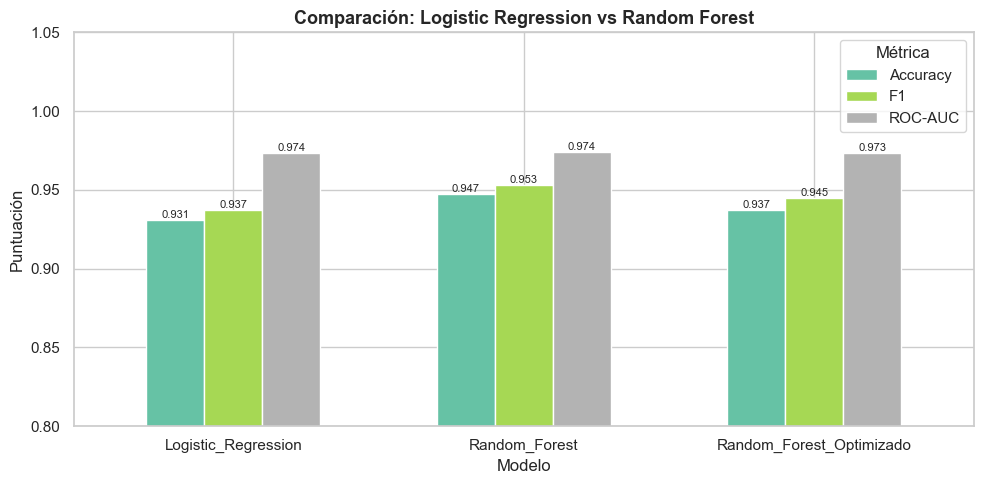


🥇 Mejor modelo por CV F1 Media: Random_Forest
   F1 test  = 0.9532
   ROC-AUC  = 0.9742
   CV F1    = 0.9324 ± 0.0188


In [248]:
# ─── Tabla comparativa ────────────────────────────────────────────────────────
resultados = [res_lr, res_rf, res_rf_opt]
cols_metricas = ['Modelo','Accuracy','Precision','Recall','F1','ROC-AUC','CV F1 Media','CV F1 Std']
df_resultados = pd.DataFrame(resultados)[cols_metricas].set_index('Modelo').round(4)

print('📊 Comparación de Modelos:')
print(df_resultados.to_string())

# ─── Gráfico comparativo ──────────────────────────────────────────────────────
metricas_plot = ['Accuracy', 'F1', 'ROC-AUC']
fig, ax = plt.subplots(figsize=(10, 5))
df_resultados[metricas_plot].plot(kind='bar', ax=ax, colormap='Set2',
                                edgecolor='white', width=0.6)
ax.set_title('Comparación: Logistic Regression vs Random Forest',
            fontsize=13, fontweight='bold')
ax.set_ylabel('Puntuación')
ax.set_ylim(0.80, 1.05)
ax.legend(title='Métrica')
ax.tick_params(axis='x', rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.show()

# Criterio: F1 (más robusto que F1 en test)
mejor = df_resultados['F1'].idxmax()
print(f'\n🥇 Mejor modelo por CV F1 Media: {mejor}')
print(f'   F1 test  = {df_resultados.loc[mejor, "F1"]:.4f}')
print(f'   ROC-AUC  = {df_resultados.loc[mejor, "ROC-AUC"]:.4f}')
print(f'   CV F1    = {df_resultados.loc[mejor, "CV F1 Media"]:.4f} ± {df_resultados.loc[mejor, "CV F1 Std"]:.4f}')


El optimizado mejora CV F1 en solo +0.004. A cambio, sacrifica Precision en -0.016, lo que significa más falsos positivos (cafés No Specialty clasificados como Specialty). ROC-AUC también baja. El Recall, que es la métrica de negocio clave, es idéntico en ambos. No hay trade-off que justifique el cambio. Por ese motivo RF Base como modelo ganador por balance global de métricas.

---
## 🔬 BLOQUE 10 — Análisis del Modelo Ganador

Con el mejor modelo hacemos tres análisis:
- **Matriz de confusión:** qué errores comete y de qué tipo
- **Curva ROC:** qué tan bien separa clases a distintos umbrales
- **Feature Importance:** qué variables usa más el modelo para decidir


🏆 Modelo ganador: Random_Forest


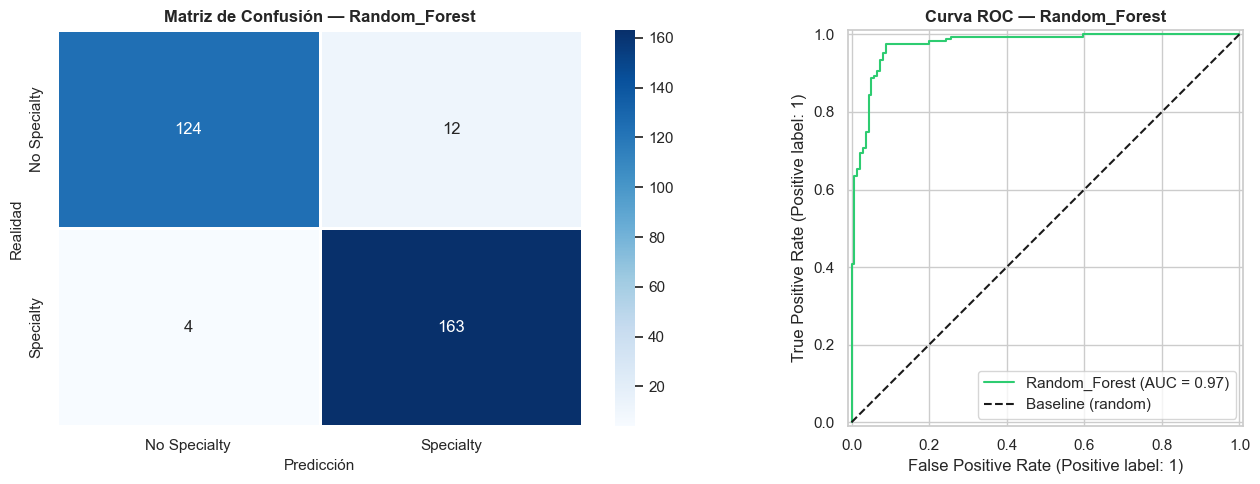

✅ Verdaderos Positivos  (Specialty correcto):        163
✅ Verdaderos Negativos  (No Specialty correcto):     124
❌ Falsos Positivos  (No Specialty → predijo Specialty): 12
❌ Falsos Negativos  (Specialty → predijo No Specialty): 4


In [ ]:
# ─── Seleccionar modelo ganador ──────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 10 — Análisis del modelo ganador
# ─────────────────────────────────────────────────────────────────────────────

# Selección automática por CV F1 Media
modelos_dict = {
    'Logistic_Regression'    : (res_lr['modelo_obj'],      X_test_scaled),
    'Random_Forest'          : (res_rf['modelo_obj'],      X_test),
    'Random_Forest_Optimizado': (res_rf_opt['modelo_obj'], X_test),
}

mejor_modelo_key = max(
    modelos_dict.keys(),
    key=lambda k: next(r['F1'] for r in resultados if r['modelo_obj'] == modelos_dict[k][0])
)

modelo_ganador, X_test_ganador = modelos_dict[mejor_modelo_key]
print(f"🏆 Modelo ganador: {mejor_modelo_key}")

# ─── Predicciones finales ─────────────────────────────────────────────────────
y_pred_final = modelo_ganador.predict(X_test_ganador)
y_prob_final = modelo_ganador.predict_proba(X_test_ganador)[:, 1]

# ─── Matriz de confusión ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Specialty','Specialty'],
            yticklabels=['No Specialty','Specialty'],
            linewidths=2, ax=axes[0])
axes[0].set_xlabel('Predicción', fontsize=11)
axes[0].set_ylabel('Realidad', fontsize=11)
axes[0].set_title(f'Matriz de Confusión — {mejor}', fontweight='bold')

# ─── Curva ROC ────────────────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_test, y_prob_final,
    name=mejor, color='#2ecc71', ax=axes[1])
axes[1].plot([0,1],[0,1],'k--', label='Baseline (random)')
axes[1].set_title(f'Curva ROC — {mejor}', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'✅ Verdaderos Positivos  (Specialty correcto):        {tp}')
print(f'✅ Verdaderos Negativos  (No Specialty correcto):     {tn}')
print(f'❌ Falsos Positivos  (No Specialty → predijo Specialty): {fp}')
print(f'❌ Falsos Negativos  (Specialty → predijo No Specialty): {fn}')


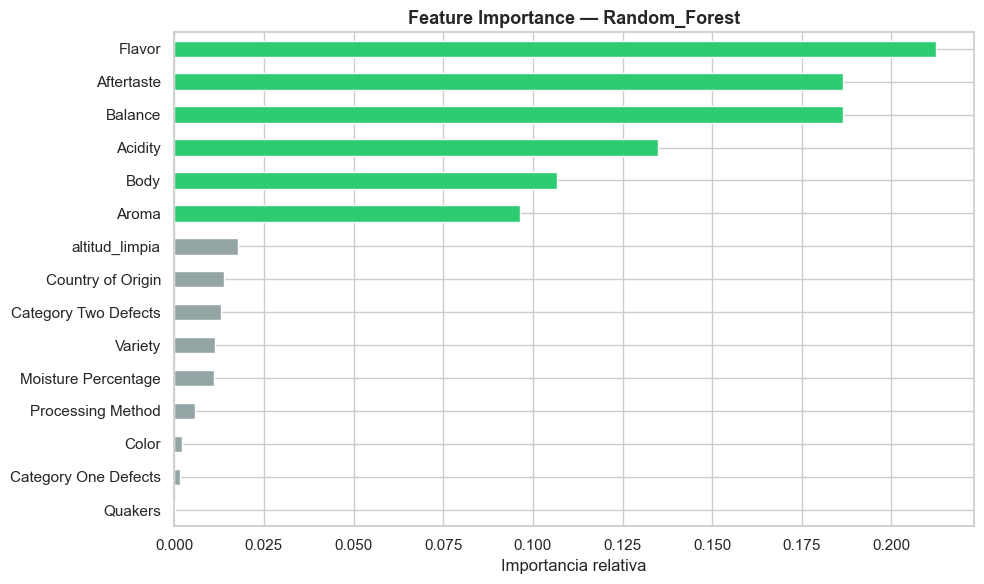

📊 Top 5 variables más importantes:
Flavor        0.2124
Aftertaste    0.1864
Balance       0.1863
Acidity       0.1348
Body          0.1067


In [250]:
# ─── Feature Importance ──────────────────────────────────────────────────────
if hasattr(modelo_ganador, 'feature_importances_'):
    importancias = pd.Series(
        modelo_ganador.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True)  # ascending para barh legible

    colores = ['#2ecc71' if v >= importancias.quantile(0.6) else '#95a5a6'
                for v in importancias.values]

    plt.figure(figsize=(10, 6))
    importancias.plot(kind='barh', color=colores, edgecolor='white')
    plt.xlabel('Importancia relativa')
    plt.title(f'Feature Importance — {mejor}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('📊 Top 5 variables más importantes:')
    print(importancias.sort_values(ascending=False).head().round(4).to_string())
else:
    # Logistic Regression: usar valor absoluto de coeficientes
    coefs = pd.Series(
        np.abs(modelo_ganador.coef_[0]),
        index=X.columns
    ).sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    coefs.plot(kind='barh', color='#3498db', edgecolor='white')
    plt.xlabel('|Coeficiente| (importancia relativa)')
    plt.title('🔍 Importancia de variables — Logistic Regression', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('📊 Top 5 coeficientes más altos:')
    print(coefs.sort_values(ascending=False).head().round(4).to_string())


---
## 💾 BLOQUE 11 — Guardar el modelo

Guardamos **todos** los artefactos necesarios para la app Streamlit:
- `model.pkl` → el modelo entrenado
- `scaler.pkl` → el escalador (para transformar datos nuevos igual que en train)
- `encoders.pkl` → los LabelEncoders (para codificar categorías nuevas igual que en train)
- `feature_names.pkl` → el orden exacto de columnas que espera el modelo

⚠️ Si falta cualquiera de estos 4 archivos, la app de predicción fallará.

In [251]:
# ─── Guardar modelo, scaler, encoders y feature_names ────────────────────────
import os
os.makedirs('../models', exist_ok=True)

# Modelo ganador
joblib.dump(modelo_ganador, f'../models/model_{mejor}.pkl')

# Scaler (necesario si el modelo ganador es Logistic Regression)
joblib.dump(scaler, f'../models/scaler_{mejor}.pkl')

# Encoders de categóricas (necesario para transformar datos nuevos en la app)
joblib.dump(encoders, f'../models/encoders_{mejor}.pkl')

# Lista de columnas en el orden exacto del entrenamiento
joblib.dump(list(X.columns), f'../models/feature_names_{mejor}.pkl')

# Nombre del modelo ganador (útil para la app)
joblib.dump(mejor, '../models/model_name.pkl')

print(f'✅ model.pkl         → modelo ganador ({mejor})')
print(f'✅ scaler.pkl        → StandardScaler entrenado en train')
print(f'✅ encoders.pkl      → LabelEncoders de {list(encoders.keys())}')
print(f'✅ feature_names.pkl → {list(X.columns)}')
print(f'\n🏆 Modelo final: {mejor}')
print(f'   F1      = {df_resultados.loc[mejor, "F1"]:.4f}')
print(f'   ROC-AUC = {df_resultados.loc[mejor, "ROC-AUC"]:.4f}')


✅ model.pkl         → modelo ganador (Random_Forest)
✅ scaler.pkl        → StandardScaler entrenado en train
✅ encoders.pkl      → LabelEncoders de ['Color', 'Country of Origin', 'Processing Method', 'Variety']
✅ feature_names.pkl → ['Acidity', 'Aftertaste', 'Aroma', 'Balance', 'Body', 'Category One Defects', 'Category Two Defects', 'Color', 'Country of Origin', 'Flavor', 'Moisture Percentage', 'Processing Method', 'Quakers', 'Variety', 'altitud_limpia']

🏆 Modelo final: Random_Forest
   F1      = 0.9532
   ROC-AUC = 0.9742


In [252]:
# Comparar umbrales en Logistic Regression (experimento)
y_prob_lr = res_lr['modelo_obj'].predict_proba(X_test_scaled)[:, 1]

for umbral in [0.50, 0.45, 0.40]:
    y_pred_umbral = (y_prob_lr >= umbral).astype(int)
    print(f"Umbral {umbral}: "
            f"F1={f1_score(y_test, y_pred_umbral):.4f} | "
            f"Recall={recall_score(y_test, y_pred_umbral):.4f} | "
            f"Precision={precision_score(y_test, y_pred_umbral):.4f}")

Umbral 0.5: F1=0.9369 | Recall=0.9341 | Precision=0.9398
Umbral 0.45: F1=0.9471 | Recall=0.9641 | Precision=0.9306
Umbral 0.4: F1=0.9507 | Recall=0.9820 | Precision=0.9213


════════════════════════════════════════════════════════════
### ANÁLISIS DE UMBRALES — DECISIÓN DE NEGOCIO
════════════════════════════════════════════════════════════

Modelo ganador por defecto:
  Random Forest (umbral=0.50) → F1=0.953 | Recall=0.976

Alternativa si se prioriza no perder Specialty:
  Logistic Regression (umbral=0.40) → F1=0.951 | Recall=0.982

💡 El umbral es una decisión de negocio:
   - Umbral bajo → detecta más Specialty reales (menos ingresos perdidos)
   - Umbral alto → menos falsos Specialty (más confianza del comprador)


---

> En nuestro caso el trade-off concreto con tus 303 muestras de test: pasas de dejar escapar ~11 cafés Specialty (con umbral 0.5) a dejar escapar solo ~3 (con umbral 0.4). A cambio, clasificas incorrectamente como Specialty unos ~11 No Specialty adicionales.